In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import numpy as np
import ast

# =========================================================
# 1. LOAD DATA
# =========================================================
FLOW_FILE        = "../data/output/park_flows_property_10km.csv"
PARKS_AUDIT_FILE = "../data/output/parks_audit.csv"
TRACT_AGG_FILE   = "../data/intermediate/tract_park_aggregation.csv"
PK_AGG_FILE      = "../data/intermediate/placekey_aggregation.csv"
TRACT_SHP_PATH   = "../data/raw/census/tl_2023_36_tract.shp"
PARK_PROPS_PATH  = "../data/raw/park_properties/geo_export_d47a2214-9d99-4d6d-b889-0aa5a59bb182.shp"

print("Loading data...")
final_df  = pd.read_csv(FLOW_FILE)
parks_df  = pd.read_csv(PARKS_AUDIT_FILE)
tract_agg = pd.read_csv(TRACT_AGG_FILE)
pk_agg    = pd.read_csv(PK_AGG_FILE)
print(f"Flow rows: {len(final_df)}")
print(f"Audit rows: {len(parks_df)}")

In [ ]:
# =========================================================
# 2. VISIT DISTRIBUTION — Properties (Central Park excluded)
# =========================================================

# M010 (Central Park) is excluded because it dwarfs every other park and
# would compress the rest of the distribution into the bottom of the chart.
# Sort ascending so the long-tail shape is visually obvious.
park_visit_totals = (
    final_df[final_df['gis_prop_num'] != 'M010']
    .groupby('gis_prop_num')['visits'].sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(15, 6))
plt.bar(range(len(park_visit_totals)), park_visit_totals.values, width=1.0, color='teal', edgecolor='none')
plt.title('Total Visits per NYC Park Property (Sorted Ascending)', fontsize=15)
plt.xlabel(f'Individual Properties (N={len(park_visit_totals)})', fontsize=12)
plt.ylabel('Total Cumulative Visits', fontsize=12)
plt.xticks([])
plt.tight_layout()
plt.show()

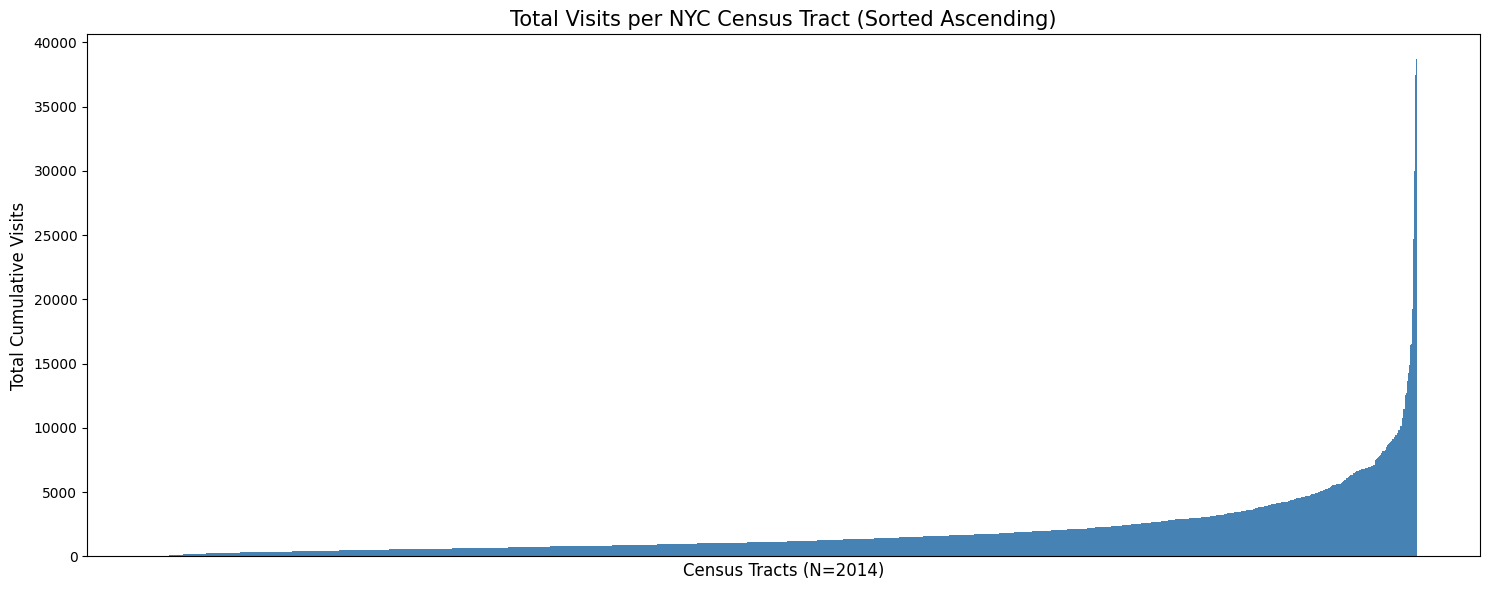

In [13]:
# =========================================================
# 3. VISIT DISTRIBUTION — Tracts
# =========================================================
tract_visit_totals = tract_agg['total_visits'].sort_values(ascending=True).reset_index(drop=True)

plt.figure(figsize=(15, 6))
plt.bar(range(len(tract_visit_totals)), tract_visit_totals.values, width=1.0, color='steelblue', edgecolor='none')
plt.title('Total Visits per NYC Census Tract (Sorted Ascending)', fontsize=15)
plt.xlabel(f'Census Tracts (N={len(tract_visit_totals)})', fontsize=12)
plt.ylabel('Total Cumulative Visits', fontsize=12)
plt.xticks([])
plt.tight_layout()
plt.show()


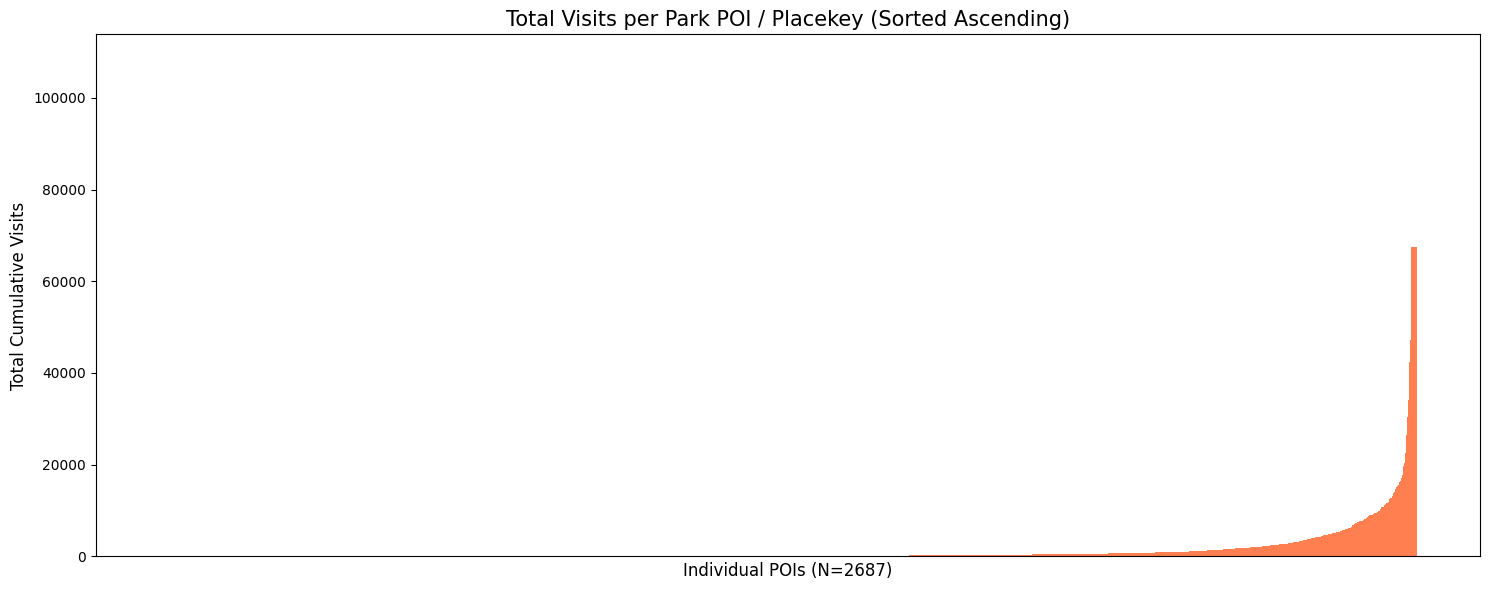

In [14]:
# =========================================================
# 4. VISIT DISTRIBUTION — Placekeys
# =========================================================
pk_visit_totals = pk_agg['total_visits'].sort_values(ascending=True).reset_index(drop=True)

plt.figure(figsize=(15, 6))
plt.bar(range(len(pk_visit_totals)), pk_visit_totals.values, width=1.0, color='coral', edgecolor='none')
plt.title('Total Visits per Park POI / Placekey (Sorted Ascending)', fontsize=15)
plt.xlabel(f'Individual POIs (N={len(pk_visit_totals)})', fontsize=12)
plt.ylabel('Total Cumulative Visits', fontsize=12)
plt.xticks([])
plt.tight_layout()
plt.show()


In [ ]:
# =========================================================
# 5. TRACT DIVERSITY — Unique parks visited per tract
# =========================================================

# park_visits is stored as a string repr of a list of [park, dist, visits]
# triplets. ast.literal_eval safely parses it back; len() gives the count
# of unique parks visited from each tract.
tract_agg['num_parks'] = tract_agg['park_visits'].apply(
    lambda x: len(ast.literal_eval(x))
)
num_parks_sorted = tract_agg['num_parks'].sort_values(ascending=True).reset_index(drop=True)

plt.figure(figsize=(15, 6))
plt.bar(range(len(num_parks_sorted)), num_parks_sorted.values, width=1.0, color='mediumseagreen', edgecolor='none')
plt.title('Number of Unique Parks Visited per Census Tract (Sorted Ascending)', fontsize=15)
plt.xlabel(f'Census Tracts (N={len(num_parks_sorted)})', fontsize=12)
plt.ylabel('Unique Parks Visited', fontsize=12)
plt.xticks([])
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# 6. POI REACH — Unique tracts per placekey
# num_tracts is pre-computed in 04_aggregation.ipynb
# =========================================================
num_tracts_sorted = pk_agg['num_tracts'].sort_values(ascending=True).reset_index(drop=True)

plt.figure(figsize=(15, 6))
plt.bar(range(len(num_tracts_sorted)), num_tracts_sorted.values, width=1.0, color='mediumpurple', edgecolor='none')
plt.title('Number of Unique Tracts Visiting Each Park POI (Sorted Ascending)', fontsize=15)
plt.xlabel(f'Individual POIs (N={len(num_tracts_sorted)})', fontsize=12)
plt.ylabel('Unique Census Tracts', fontsize=12)
plt.xticks([])
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# 7. TOP 10 MOST VISITED PROPERTIES
# =========================================================

# Sum visits across every tract→property flow, then take the 10 largest.
park_rankings = final_df.groupby(['gis_prop_num', 'property_name'])['visits'].sum().reset_index()
top_10 = park_rankings.nlargest(10, 'visits')

# Attach acres + Forever Wild status from the audit. drop_duplicates keeps
# one row per property in case the audit has multiple POIs per property.
prop_attrs = (
    parks_df[['gis_prop_num', 'acres', 'forever_wild_id']]
    .drop_duplicates(subset='gis_prop_num')
)
top_10 = top_10.merge(prop_attrs, on='gis_prop_num', how='left')
top_10 = top_10[[
    'gis_prop_num', 'property_name', 'visits', 'acres', 'forever_wild_id'
]].rename(columns={'visits': 'total_visits'})

print("\n--- Top 10 Most Visited Properties ---")
print(top_10.to_string(index=False))

In [ ]:
# =========================================================
# 8. POI HEATMAP — Visit intensity by location
# Forever Wild properties indicated with black outline
# =========================================================
import os
import warnings
import matplotlib.colors
import contextily as ctx
warnings.filterwarnings('ignore')

# Re-load Advan POI coordinates (they aren't carried in the audit)
ADVAN_PATH = "../data/raw/advan"
advan_files = [os.path.join(ADVAN_PATH, f) for f in os.listdir(ADVAN_PATH) if f.endswith('.csv')]
coords_list = []
for f in advan_files:
    coords_list.append(pd.read_csv(f, usecols=['PLACEKEY', 'LATITUDE', 'LONGITUDE']).drop_duplicates('PLACEKEY'))
coords = pd.concat(coords_list).drop_duplicates('PLACEKEY').rename(columns={'PLACEKEY': 'placekey'})

# Join coordinates back onto the audit so each placekey carries lat/lon
poi_map = parks_df[['placekey', 'gis_prop_num', 'visits', 'forever_wild_id']].merge(coords, on='placekey', how='left')
poi_map = poi_map.dropna(subset=['LATITUDE', 'LONGITUDE', 'visits'])

# Collapse multiple POIs per property: average lat/lon to get a "centroid",
# sum visits, and OR forever_wild_id flag across rows.
prop_map = poi_map.groupby('gis_prop_num').agg(
    lat=('LATITUDE', 'mean'),
    lon=('LONGITUDE', 'mean'),
    total_visits=('visits', 'sum'),
    forever_wild=('forever_wild_id', lambda x: x.notna().any())
).reset_index()

# Reproject to Web Mercator (EPSG:3857) for tile-provider compatibility
prop_gdf = gpd.GeoDataFrame(
    prop_map,
    geometry=gpd.points_from_xy(prop_map['lon'], prop_map['lat']),
    crs='EPSG:4326'
).to_crs('EPSG:3857')

# Log scale because visit counts span several orders of magnitude
vmin = max(prop_gdf['total_visits'].min(), 1)
vmax = prop_gdf['total_visits'].max()
norm = matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(figsize=(12, 14))

# Two-pass scatter: non-Forever Wild first, then FW on top so the black
# outlines aren't obscured by overlapping non-FW points.
non_fw = prop_gdf[~prop_gdf['forever_wild']]
sc = ax.scatter(
    non_fw.geometry.x, non_fw.geometry.y,
    c=non_fw['total_visits'], cmap='viridis',
    norm=norm,
    s=40, alpha=0.85, linewidths=0, zorder=3
)

fw = prop_gdf[prop_gdf['forever_wild']]
ax.scatter(
    fw.geometry.x, fw.geometry.y,
    c=fw['total_visits'], cmap='viridis',
    norm=norm,
    s=40, alpha=0.95, edgecolors='black', linewidths=1.2, zorder=4
)

# Tight extent: bounding box of the POI scatter itself, with a small
# margin so points near the edge aren't clipped to the axis line.
minx, miny, maxx, maxy = prop_gdf.total_bounds
margin_x = (maxx - minx) * 0.03
margin_y = (maxy - miny) * 0.03
ax.set_xlim(minx - margin_x, maxx + margin_x)
ax.set_ylim(miny - margin_y, maxy + margin_y)

# Minimalist CartoDB Positron basemap
ctx.add_basemap(ax, crs='EPSG:3857', source=ctx.providers.CartoDB.Positron, zorder=1)

plt.colorbar(sc, ax=ax, label='Total Visits (log scale)')

# Custom legend patch for the FW outline (scatter doesn't auto-legend it)
fw_patch = mpatches.Patch(facecolor='white', edgecolor='black', linewidth=1.2, label='Forever Wild')
ax.legend(handles=[fw_patch], loc='lower right', fontsize=10)

ax.set_title('NYC Park POI Visit Intensity\n(color = visits log scale; black outline = Forever Wild)', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# 9. CHOROPLETH — Visits to Prospect Park (B073) by tract
# =========================================================
PROSPECT_PROP = 'B073'

# Restrict the flow file to Prospect Park rows only — one record per tract
prospect_flows = final_df[final_df['gis_prop_num'] == PROSPECT_PROP][['tract_i', 'visits']].copy()
prospect_flows['tract_i'] = prospect_flows['tract_i'].astype(str)
print(f"Tracts visiting Prospect Park: {len(prospect_flows)}")

# Web Mercator for tile compatibility
tracts = gpd.read_file(TRACT_SHP_PATH)
nyc_counties = ['005', '047', '061', '081', '085']
nyc_tracts = tracts[tracts['COUNTYFP'].isin(nyc_counties)].copy().to_crs('EPSG:3857')
nyc_tracts['GEOID'] = nyc_tracts['GEOID'].astype(str)

# Left-join brings 'visits' onto every tract; tracts that don't visit
# Prospect Park keep NaN.
nyc_tracts = nyc_tracts.merge(prospect_flows, left_on='GEOID', right_on='tract_i', how='left')

# Property polygon for an outline overlay
parks_shp = gpd.read_file(PARK_PROPS_PATH).to_crs('EPSG:3857')
prospect_poly = parks_shp[parks_shp['gispropnum'] == PROSPECT_PROP].dissolve()

fig, ax = plt.subplots(figsize=(14, 14))

# Tracts with visits get the colormap
visit_tracts = nyc_tracts[nyc_tracts['visits'].notna()]
visit_tracts.plot(
    ax=ax, column='visits', cmap='Blues',
    edgecolor='#aaaaaa', linewidth=0.2, alpha=0.8,
    legend=True,
    legend_kwds={'label': 'Visits to Prospect Park', 'shrink': 0.5}
)

# Tight extent: bounds of the visit tracts unioned with the park polygon
# itself, in case the park sits at the edge of the visiting tracts.
union_bounds = pd.concat([visit_tracts.geometry, prospect_poly.geometry]).total_bounds
minx, miny, maxx, maxy = union_bounds
margin_x = (maxx - minx) * 0.03
margin_y = (maxy - miny) * 0.03
ax.set_xlim(minx - margin_x, maxx + margin_x)
ax.set_ylim(miny - margin_y, maxy + margin_y)

# Outline Prospect Park itself in green
prospect_poly.plot(ax=ax, color='none', edgecolor='green', linewidth=2.5, zorder=5)

# Minimalist CartoDB Positron basemap, drawn underneath everything else
ctx.add_basemap(ax, crs='EPSG:3857', source=ctx.providers.CartoDB.Positron, zorder=0)

green_patch = mpatches.Patch(facecolor='none', edgecolor='green', linewidth=2, label='Prospect Park (B073)')
ax.legend(handles=[green_patch], loc='lower right', fontsize=10)

ax.set_title('Visits to Prospect Park (B073) by Census Tract', fontsize=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# 10. NYC PARKS + NATURE AREAS MAP
# Light green: all NYC park properties
# Dark green : Forever Wild (nature) sites within those properties
# =========================================================
NYC_WILD_CSV_PATH = "../data/raw/forever_wild/NYC_Parks_Forever_Wild_20260205.csv"

# Load every NYC park polygon and reproject for tile compatibility
parks_all = gpd.read_file(PARK_PROPS_PATH).to_crs('EPSG:3857')

# Identify which gispropnum values have any Forever Wild site. We don't
# need the FW polygons themselves — just the property-level flag — since
# nature_fraction in the audit already encodes "how much" is FW.
fw_props = set(
    pd.read_csv(NYC_WILD_CSV_PATH)
      .rename(columns=lambda c: c.strip())['GISPropNum']
      .dropna()
      .unique()
)
parks_all['is_fw'] = parks_all['gispropnum'].isin(fw_props)

print(f"Total park polygons: {len(parks_all):,}")
print(f"  Forever Wild     : {parks_all['is_fw'].sum():,}")
print(f"  Standard parks   : {(~parks_all['is_fw']).sum():,}")

fig, ax = plt.subplots(figsize=(13, 14))

# Standard parks first, light green. edgecolor stays subtle to avoid
# visual clutter at zoom levels where individual playgrounds are tiny.
parks_all[~parks_all['is_fw']].plot(
    ax=ax, color='#a8d8a8', edgecolor='#5fa05f', linewidth=0.3, alpha=0.85, zorder=2
)

# Forever Wild on top in a darker green
parks_all[parks_all['is_fw']].plot(
    ax=ax, color='#1e6b1e', edgecolor='#0a3d0a', linewidth=0.4, alpha=0.95, zorder=3
)

# Tight extent: bounding box of all park polygons themselves
minx, miny, maxx, maxy = parks_all.total_bounds
margin_x = (maxx - minx) * 0.03
margin_y = (maxy - miny) * 0.03
ax.set_xlim(minx - margin_x, maxx + margin_x)
ax.set_ylim(miny - margin_y, maxy + margin_y)

# Minimalist CartoDB Positron basemap underneath
ctx.add_basemap(ax, crs='EPSG:3857', source=ctx.providers.CartoDB.Positron, zorder=1)

park_patch    = mpatches.Patch(facecolor='#a8d8a8', edgecolor='#5fa05f', label='NYC Parks')
nature_patch  = mpatches.Patch(facecolor='#1e6b1e', edgecolor='#0a3d0a', label='Forever Wild (Nature)')
ax.legend(handles=[park_patch, nature_patch], loc='lower right', fontsize=11, frameon=True)

ax.set_title('NYC Parks and Forever Wild Nature Areas', fontsize=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# 11. CHOROPLETH — Visits to Central Park (M010) by tract
# =========================================================
CENTRAL_PROP = 'M010'

# Restrict the flow file to Central Park rows only — one record per tract
central_flows = final_df[final_df['gis_prop_num'] == CENTRAL_PROP][['tract_i', 'visits']].copy()
central_flows['tract_i'] = central_flows['tract_i'].astype(str)
print(f"Tracts visiting Central Park: {len(central_flows)}")

# Web Mercator for tile compatibility
tracts = gpd.read_file(TRACT_SHP_PATH)
nyc_counties = ['005', '047', '061', '081', '085']
nyc_tracts_cp = tracts[tracts['COUNTYFP'].isin(nyc_counties)].copy().to_crs('EPSG:3857')
nyc_tracts_cp['GEOID'] = nyc_tracts_cp['GEOID'].astype(str)

# Left-join brings 'visits' onto every tract; tracts that don't visit
# Central Park keep NaN.
nyc_tracts_cp = nyc_tracts_cp.merge(central_flows, left_on='GEOID', right_on='tract_i', how='left')

# Property polygon for the green outline overlay
parks_shp_cp = gpd.read_file(PARK_PROPS_PATH).to_crs('EPSG:3857')
central_poly = parks_shp_cp[parks_shp_cp['gispropnum'] == CENTRAL_PROP].dissolve()

fig, ax = plt.subplots(figsize=(14, 14))

# Visit-count tracts with the colormap. Note: Central Park hits the Advan
# 709,622 visit cap so the high end of the colormap is saturated — the
# heaviest visitor tracts may be undifferentiable at the top end.
visit_tracts_cp = nyc_tracts_cp[nyc_tracts_cp['visits'].notna()]
visit_tracts_cp.plot(
    ax=ax, column='visits', cmap='Reds',
    edgecolor='#aaaaaa', linewidth=0.2, alpha=0.8,
    legend=True,
    legend_kwds={'label': 'Visits to Central Park', 'shrink': 0.5}
)

# Tight extent: bounds of visit tracts unioned with the park polygon
union_bounds_cp = pd.concat([visit_tracts_cp.geometry, central_poly.geometry]).total_bounds
minx, miny, maxx, maxy = union_bounds_cp
margin_x = (maxx - minx) * 0.03
margin_y = (maxy - miny) * 0.03
ax.set_xlim(minx - margin_x, maxx + margin_x)
ax.set_ylim(miny - margin_y, maxy + margin_y)

# Outline Central Park itself in green
central_poly.plot(ax=ax, color='none', edgecolor='green', linewidth=2.5, zorder=5)

# Minimalist CartoDB Positron basemap underneath
ctx.add_basemap(ax, crs='EPSG:3857', source=ctx.providers.CartoDB.Positron, zorder=0)

green_patch = mpatches.Patch(facecolor='none', edgecolor='green', linewidth=2, label='Central Park (M010)')
ax.legend(handles=[green_patch], loc='lower right', fontsize=10)

ax.set_title('Visits to Central Park (M010) by Census Tract', fontsize=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()